In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tsai.all import *
from tsai.inference import load_learner
from sklearn.preprocessing import MinMaxScaler
import pdb
from IPython.display import clear_output as clear


In [2]:
#### 训练并保存模型

# ts = get_forecasting_time_series("Sunspots").values
df = pd.read_csv('Persona 5 Royal.csv')
sc = MinMaxScaler(feature_range=(0, 1))
ts = sc.fit_transform(df['Owners'].values.reshape(-1, 1)).astype('float64')
window_length = 8 # 使用多少个时间步长来预测下一个
horizon = 1       # 预测未来的时间步长数
pred_len = 7 
X, y = SlidingWindow(window_length, horizon=horizon)(ts)
splits = TimeSplitter(pred_len)(y) 
tfms = [None, TSForecasting()]
batch_tfms = TSStandardize()
#"RNN", "LSTM", "GRU", "MLP", "FCN", 'ResNet', 'LSTM_FCN', 'GRU_FCN', 
# 'mWDN', 'TCN', 'MLSTM_FCN', 'InceptionTime',  'XceptionTime', 
# 'ResCNN',  'OmniScaleCNN', 'TST',  'TSiT',  'XCM', 'gMLP',  'TSSequencerPlus', 
# 这些不行(可能要修改默认参数 )：'Rocket', 'TabModel', 'TabTransformer', 'MiniRocket','TSPerceiver', 'GatedTabTransformer', 'PatchTST'
for models_name in ["RNN", "LSTM", "GRU", "MLP", "FCN", 'ResNet', 'LSTM_FCN', 'GRU_FCN', 
                    'mWDN', 'TCN', 'MLSTM_FCN', 'InceptionTime',  'XceptionTime',  'ResCNN',  
                    'OmniScaleCNN', 'TST',  'TSiT',  'XCM', 'gMLP',  'TSSequencerPlus', ]:
    fcst = TSForecaster(X, y, splits=splits, path='models_Persona', tfms=tfms, batch_tfms=batch_tfms, bs=512, arch=models_name, metrics=[mae, mse, mape, rmse], cbs=ShowGraph())
    fcst.fit_one_cycle(100, 1e-3)
    fcst.export("Persona_"+models_name+".pkl")

    clear()

In [3]:
#### 测试并保存数据

for models_name in ["RNN", "LSTM", "GRU", "MLP", "FCN", 'ResNet', 'LSTM_FCN', 'GRU_FCN', 
                    'mWDN', 'TCN', 'MLSTM_FCN', 'InceptionTime',  'XceptionTime',  'ResCNN',  
                    'OmniScaleCNN', 'TST',  'TSiT',  'XCM', 'gMLP',  'TSSequencerPlus', ]:

    fcst = load_learner("models_Persona/"+"Persona_"+models_name+".pkl", cpu=False)
    raw_preds, target, preds = fcst.get_X_preds(X[splits[1]], y[splits[1]])
    target = sc.inverse_transform(np.array(target).reshape(-1, 1)).astype('int').flatten()
    preds = sc.inverse_transform(np.array(preds).reshape(-1, 1)).astype('int').flatten()

    pd.DataFrame({'date': df['date'].values[-pred_len:], 'Owners': preds}).to_csv('results_Persona/Persona_'+models_name+'preds_'+str(pred_len)+'.csv', index=False)
    # plt.plot(target)
    # plt.plot(preds)
    # plt.suptitle('tsai Prediction', )
    # plt.legend(['target', 'preds']) # , loc='upper left'
    # # plt.xticks(range(0, len(testY_index), 10), testY_index[::10], rotation=75)
    # plt.savefig('figs/Persona_'+models_name+'_Predictions.png', bbox_inches='tight')
    # plt.show()

In [4]:
#### metrics

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def get_metric(actual, predicted):
    # 计算MAE
    mae = mean_absolute_error(actual, predicted)
    # 计算MAPE
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    # 计算MSE
    mse = mean_squared_error(actual, predicted)
    # 计算RMSE
    rmse = np.sqrt(mse)
    # 计算R^2
    r2 = r2_score(actual, predicted)
    return mae, mape, mse, rmse, r2

df_t = pd.read_csv('results_persona/target.csv')['Owners']
df_9 = pd.read_csv('results_persona/trend_9.csv')['Owners']

model_list = ["RNN", "LSTM", "GRU", "MLP", "FCN", 'ResNet', 'LSTM_FCN', 'GRU_FCN', 
                    'mWDN', 'TCN', 'MLSTM_FCN', 'InceptionTime',  'XceptionTime',  'ResCNN',  
                    'OmniScaleCNN', 'TST',  'TSiT',  'XCM', 'gMLP',  'TSSequencerPlus']


for models_name in model_list:
    df = pd.read_csv('results_persona/persona_'+models_name+'preds_7.csv')['Owners']
    mae, mape, mse, rmse, r2 = get_metric(df, df_t)
    print(mae, mape, mse, rmse, r2)


3201.8571428571427 0.3387028074973586 11038349.0 3322.4010895736233 -47.394179965663774
31339.85714285714 3.198727513351495 982458461.5714285 31344.19342671667 -1041.340362307431
36424.0 3.6984251813162783 1326914612.0 36426.839171138636 -878.5720790113074
26173.428571428572 2.837956520938099 685327870.2857143 26178.767547111805 -743.7589010280096
7405.142857142857 0.7747611765378493 55431707.428571425 7445.247304728798 -101.64057274734073
8145.0 0.8513887970973325 67978187.0 8244.88853775477 -39.6137131140671
12000.42857142857 1.2495151837693992 144304980.14285713 12012.700784705208 -165.3985746652623
4092.285714285714 0.42965249235021413 17202227.14285714 4147.556767888433 -21.62368720827261
13925.0 1.4900549440788025 194510629.57142857 13946.706764373752 -567.9066682926223
50747.42857142857 5.078911014209863 2575582568.0 50750.19771390058 -1336.7521213693346
7790.285714285715 0.814737192152439 61282032.85714286 7828.284157920103 -174.31042025302028
26293.85714285714 2.69752816136782

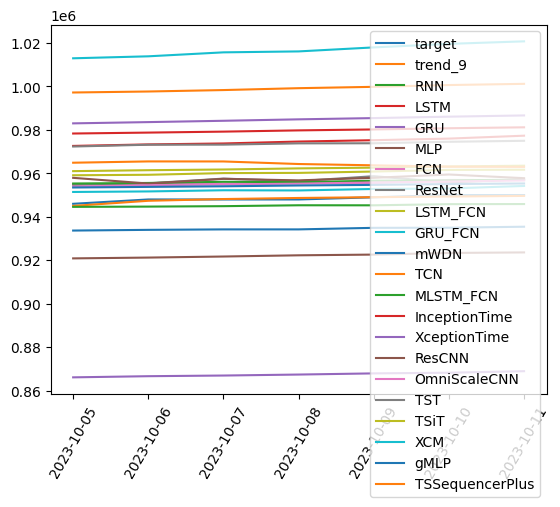

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import savemat

df_t = pd.read_csv('results_persona/target.csv')
date = df_t['date']
df_t = df_t['Owners']
df_9 = pd.read_csv('results_persona/trend_9.csv')['Owners']
#df_RNN = pd.read_csv('results_D/Detroit_RNNpreds_14.csv')['Owners']
#df_LSTM = pd.read_csv('results_D/Detroit_LSTMpreds_14.csv')['Owners']
#df_FCN = pd.read_csv('results_D/Detroit_FCNpreds_14.csv')['Owners']
#df_ResNet = pd.read_csv('results_D/Detroit_ResNetpreds_14.csv')['Owners']
#df_TST = pd.read_csv('results_D/Detroit_TSTpreds_14.csv')['Owners']
#plt.plot(date, df_t)
#plt.plot(date, df_9)
#plt.plot(date, df_RNN)
#plt.plot(date, df_LSTM)
#plt.plot(date, df_FCN)
#plt.plot(date, df_ResNet)
# plt.suptitle('tsai Prediction')
#plt.legend(['target', 'trend_9', 'LSTM', 'FCN'])
# plt.legend(['target', 'trend_7', 'RNN','LSTM', 'FCN']) # , loc='upper left'
#plt.xticks(range(0, len(date), 1), date[::1], rotation=75)
#plt.savefig('figs/Persona_'+models_name+'_Predictions.png', bbox_inches='tight')
#plt.show()

model_list = ["RNN", "LSTM", "GRU", "MLP", "FCN", 'ResNet', 'LSTM_FCN', 'GRU_FCN', 
                    'mWDN', 'TCN', 'MLSTM_FCN', 'InceptionTime',  'XceptionTime',  'ResCNN',  
                    'OmniScaleCNN', 'TST',  'TSiT',  'XCM', 'gMLP',  'TSSequencerPlus']

plt.plot(date, df_t)
plt.plot(date, df_9)

for models_name in model_list:
    df = pd.read_csv('results_persona/persona_'+models_name+'preds_7.csv')['Owners']
    savemat('MAT_Persona/'+models_name+".mat", {models_name: df})  # 方面后面用matlab画图，matlab处理 
    plt.plot(date, df)

plt.xticks(date, rotation=60)
plt.legend(['target', 'trend_9']+model_list)
plt.show()
